<a href="https://colab.research.google.com/github/Strojove-uceni/2024-final-julia-vendy/blob/main/Detekce_dopravnich_nehod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatická detekce dopravních nehod pomocí YOLOv8**
<p>

# Autoři: Vendula Rusá, Iuliia Shestopalova



# *Abstrakt*

Tento projekt se zaměřuje na automatickou detekci dopravních nehod na základě záznamů z pouličních kamer s využitím modelů YOLOv8. Naší hlavní motivací bylo vytvořit systém schopný automaticky upozornit policii nebo ostatní složky integrovaného záchranného systému, aby byl zkrácen čas do jejich příjezdu na místo nehody. Oproti současné situaci, kdy je nutná přítomnost svědka, který manuálně zavolá pomoc, naše řešení eliminuje tuto závislost na lidském faktoru.

V rámci projektu jsme analyzovali několik variant modelů s různými nastaveními váhových parametrů. Vybraný model dosáhl přesnosti mAP 93,7 % na confidenčním levelu 50 % a průměrné přesnosti mAP50-95 83 % na validačním datasetu. Tento model byl schopen detekovat nehody s vysokou přesností a zároveň minimalizovat falešné detekce. Klíčovou prioritou při výběru modelu bylo dosažení vysoké hodnoty recall, aby byly minimalizovány případy, kdy nehoda zůstane neodhalena.

Dataset pro trénování byl vytvořen pomocí Roboflow a zahrnoval soubor obrázků obsahujících nehody i běžné dopravní situace. Model byl dále integrován do grafického uživatelského rozhraní (GUI), které umožňuje v reálném čase analyzovat data, detekovat nehody a upozornit uživatele na jejich závažnost.

**Následující buňky obsahují instalaci potřebných knihoven ke spuštění a uložení dat a modelů.**

In [1]:
# @title
%%capture
# Install Roboflow
!pip install roboflow

# Install Ultralytics (YOLOv8)
!pip install ultralytics

# Install YOLO dependencies
!pip install torch torchvision torchaudio
!pip install matplotlib
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import zipfile
import os

In [2]:
# @title
%%capture
# data from roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="c0AKlRxmACmG83mIunVG")
project = rf.workspace("su2-d7z1e").project("road-accident-victim-detection-bytzk")
version = project.version(2)
dataset = version.download("yolov8")

In [3]:
# @title
# Načtení modelů z GitHubu a další soubory
!git clone https://github.com/Strojove-uceni/2024-final-julia-vendy.git

# Extrahování videí ze ZIP souboru
#zip_path = "su2projekt/videos.zip"
#unzip_dir = "su2projekt/videos"
#with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#    zip_ref.extractall(unzip_dir)

Cloning into '2024-final-julia-vendy'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (76/76), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 97 (delta 28), reused 46 (delta 13), pack-reused 21 (from 1)
Receiving objects: 100% (97/97), 107.47 MiB | 13.58 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (21/21), done.


# Metodologie
 Nejprve jsme vytvořili dataset kombinací veřejných dat a vlastní anotace. Použili jsme Roboflow pro snadnou anotaci a přípravu dat.

 Na obrázcích jsme chtěli anotovat výskyt nehody nebo vážné nehody. Kategorii "nehoda" pro nás tvoří situace, kdy je třeba zavolat policii. Označení "vazna nehoda" značí, že je nutný kromě policie ještě příjezd hasičů či záchranné služby. Původní dataset na Roboflow zahrnoval čtyři kategorie nehod. Kvůli nevyváženosti kategorií a jejich těžkému vyhodnocení i pro člověka jsme se rozhodly některé kategorie sloučit a doplnit obrázky bez nehod z původního datasetu dostupného na Kaggle. Na obrázky rovněž byla použita augmentace cutout a noise neboli vyříznutí části obrázku a přídání šumu. Náš dataset nakonec obsahuje 1445 obrázků, které jsme rozdělily v poměru 80:10:10 na trénovací, validační a testovací část datasetu.

Naší úlohu jsme klasifikovali jako detekci objektů, jelikož upozornění na konkrétní část záběru může zrychlit reakci člověka na kritickou situaci.

Pro detekci nehod jsme zvolili modely YOLO, jež jsou pokročilé modely pro detekci objektů známé svou rychlostí a přesností. YOLO umí velmi dobře rozpoznávat auta, což pro nás znamená, že náš model pro detekci nehod by nemuselo být potřeba trénovat dlouho.


Níže můžeme vidět grafické znázornění metrik oficiálních modelů na našich validačních datech, tak rovněž předtrénovaných modelů na našich datech na 100 epochách pro verze 8s a 11s modelu YOLO. Verze 8 je poměrně hodně rozšířená právě pro úlohy detekce objektů. Verze 11 je nejnovějším modelem od ultralytics a měla by rovněž být velmi přesná na úlohy detekce objektů. Tyto modely mají různé velikosti, které ovlivňují hloubku sítě. My jsme si vybrali velikost s, abychom měly rychlý model a zároveň zamezili rychlému předtrénování našeho modelu, jelikož máme poměrně malý dataset.




In [4]:
import numpy as np

def plot_metrics(models, split):

  # Test data path
  test_data_path = '/content/Road-accident-victim-detection-2/data.yaml'  # Assuming 'val' is defined in the .yaml file

  # Initialize metrics storage
  model_names = []
  metrics_data = {
      'Precision': [],
      'Recall': [],
      'mAP50': [],
      'mAP50-95': []
  }

  # Collect metrics for each model
  for mod in models:
      print(f"Validating model: {mod}")
      if mod.endswith('s_best.pt'):
        model_names.append(mod.replace('_best.pt', ''))  # Remove the _best.pt extension from model name
        model_path=f'/content/2024-final-julia-vendy/model_weights/{mod}'
        model = YOLO(model_path)
      elif mod.endswith('best.pt'):
        model_names.append(mod.replace('.pt', ''))  # Remove the .pt extension from model name
        model = YOLO(f'/content/2024-final-julia-vendy/{mod}')
      else:
        model_names.append(mod.replace('.pt', ''))  # Remove the .pt extension from model name
        model = YOLO(mod)


      # Validate the model on the test set
      metrics = model.val(data=test_data_path, split=split, imgsz=640)

      # Store metrics
      metrics_data['Precision'].append(metrics.box.p)
      metrics_data['Recall'].append(metrics.box.r)
      metrics_data['mAP50'].append(metrics.box.map50)
      metrics_data['mAP50-95'].append(metrics.box.map)


  # Extract class-specific metrics
  precision_nehoda = [prec[0] for prec in metrics_data['Precision']]
  recall_nehoda = [rec[0] for rec in metrics_data['Recall']]
  precision_vazna_nehoda = [prec[1] for prec in metrics_data['Precision']]
  recall_vazna_nehoda = [rec[1] for rec in metrics_data['Recall']]

  # Compute mean precision and recall
  mean_precision = [np.mean(prec) for prec in metrics_data['Precision']]
  mean_recall = [np.mean(rec) for rec in metrics_data['Recall']]


  # Plot 1: Precision and Recall for nehoda
  plt.figure(figsize=(12, 10))

  plt.subplot(2, 2, 1)  # First subplot for Precision and Recall - nehoda
  plt.plot( models, precision_nehoda, label='Precision - nehoda', marker='o')
  plt.plot( models, recall_nehoda, label='Recall - nehoda', marker='o')
  plt.title('Precision a Recall pro kategorii - nehoda')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.subplot(2, 2, 2)  # Second subplot for Precision and Recall - vazna nehoda
  plt.plot( models, precision_vazna_nehoda, label='Precision - vazna nehoda', marker='o')
  plt.plot( models, recall_vazna_nehoda, label='Recall - vazna nehoda', marker='o')
  plt.title('Precision a Recall pro kategorii - vazna nehoda')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.subplot(2, 1, 2)  # Third subplot for Aggregate Metrics
  plt.plot(models, mean_precision, label='Mean Precision', marker='o')
  plt.plot(models, mean_recall, label='Mean Recall', marker='o')
  plt.plot(models, metrics_data['mAP50'], label='mAP50', marker='o')
  plt.plot(models, metrics_data['mAP50-95'], label='mAP50-95', marker='o')
  plt.title('Průměrné metriky')
  plt.ylabel('Modely')
  plt.xlabel('Metrické hodnoty')
  plt.legend()
  plt.grid()

  plt.tight_layout()
  plt.show()



Validating model: yolov8s.pt


100%|██████████| 21.5M/21.5M [00:00<00:00, 193MB/s]
100%|██████████| 755k/755k [00:00<00:00, 22.2MB/s]
val: Scanning /content/Road-accident-victim-detection-2/valid/labels... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<00:00, 1227.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:33<00:00,  9.34s/it]


Validating model: yolo11s.pt


100%|██████████| 18.4M/18.4M [00:00<00:00, 111MB/s] 
val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:24<00:00,  8.46s/it]


Validating model: yolov8s_ac_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:38<00:00,  9.83s/it]


Validating model: yolov11s_ac_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:26<00:00,  8.66s/it]


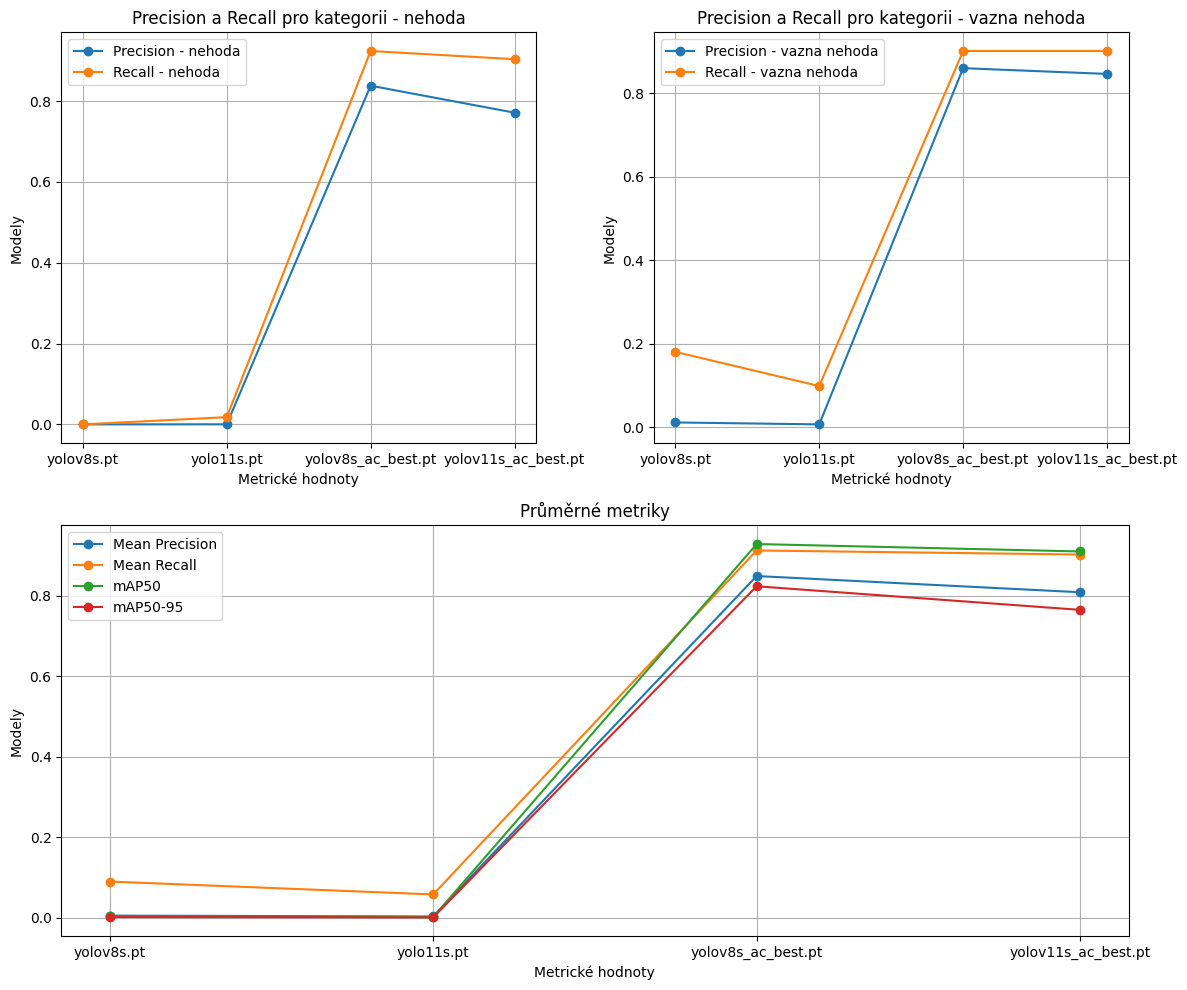

In [5]:
# List of model paths
models = [
    'yolov8s.pt',
    'yolo11s.pt',
    'yolov8s_ac_best.pt',
    'yolov11s_ac_best.pt'
]

plot_metrics(models, 'val')

Můžeme vidět, že předténováním se všechny jejich metriky zlepšily. A vzhledem k tomu, že na validačním datasetu byl lepší model YOLOv8s než YOLOv11s, tak s ním budeme dále pracovat.

### Architektura modelu

Model byl modifikován na základě původní architektury YOLOv8s. Následující tabulka shrnuje klíčové komponenty modelu:

| **Vrstva**   | **Parametry**             |
|--------------|---------------------------|
| SPPF         | `[512, 512, 5]`          |
| Detect       | `[2, [128, 256, 512]]`   |
| C2f          | Více konfigurací, např. `[64, 64, 1, True]` |

### Shrnutí rozdílů oproti YOLOv8s

Hlavní rozdíly oproti oficiální implementaci YOLOv8s zahrnují:
- **SPPF vrstva**: Změněna velikost jádra na 5 místo 3, což zvyšuje schopnost modelu zachytit větší kontext.
- **Detect vrstva**: Přizpůsobena pro dvě třídy (2) oproti standardním 80 třídám v COCO datasetu.
- **C2f bloky**: Optimalizované konfigurace bloků s různým počtem kanálů a opakováním.
- **Parametry**: Celkový počet parametrů modelu je 11,136,374.

Modifikovaná architektura je navržena pro specifické potřeby projektu a nabízí vyšší efektivitu pro cílovou úlohu detekce s dvěma třídami. Tyto úpravy optimalizují model jak z hlediska výpočetních požadavků, tak z hlediska přesnosti pro specifický dataset.


Následně jsme experimentovali s různými konfiguracemi váhových parametrů modelu (váhy pro loss bounding boxů, klasifikace a objektovost). Byly definovány čtyři různé konfigurace:
 - Default_Weights: Základní váhy pro všechny ztráty.
 - Increased_Box_Loss: Zvýšená váha pro box loss.
 - Increased_Cls_Loss: Zvýšená váha pro classification loss.
 - Increased_Obj_Loss: Zvýšená váha pro objectness loss.


\begin{array}{|c|c|c|c|}
\hline
\textbf{Name} & \textbf{Box} & \textbf{Cls} & \textbf{Obj} \\\\
\hline
Default\_Weights & 0.05 & 0.5 & 1.0 \\\\
\hline
Increased\_Box\_Loss & 0.1 & 0.5 & 1.0 \\\\
\hline
Increased\_Cls\_Loss & 0.05 & 0.6 & 1.0 \\\\
\hline
Increased\_Obj\_Loss & 0.05 & 0.5 & 1.2 \\\\
\hline
\end{array}



Každá z těchto konfigurací byla trénována na 100 epochách s počátčními vahami YOLOv8s varianty. Zde se můžeme podívat na kód využitý k trénování a vyhodnocení metrik precision, recall, mAP50 a mAP50-95 pro jednotlivé modely.

🛑🛑🛑**POZOR: Následující buňka po spuštění běží 4 hodiny.**🛑🛑🛑

In [ ]:
from ultralytics import YOLO
import torch
import os

# Get the number of available GPUs, else use CPU
ngpus = torch.cuda.device_count() if torch.cuda.is_available() else 'cpu'

# Define the path to your dataset
DATA_PATH = f"{dataset.location}/data.yaml"  # Automatically set by Roboflow

# Define a list of weight configurations to experiment with
weight_configs = [
    {'box': 0.05, 'cls': 0.5, 'obj': 1.0, 'name': 'Default_Weights'},
    {'box': 0.1, 'cls': 0.5, 'obj': 1.0, 'name': 'Increased_Box_Loss'},
    {'box': 0.05, 'cls': 0.6, 'obj': 1.0, 'name': 'Increased_Cls_Loss'},
   {'box': 0.05, 'cls': 0.5, 'obj': 1.2, 'name': 'Increased_Obj_Loss'},
]

# Results directory
results_dir = "accident_detection_results"
os.makedirs(results_dir, exist_ok=True)

# Train models with different weight configurations
for config in weight_configs:
    print(f"Training model with configuration: {config['name']}")

    # Initialize YOLO model
    model = YOLO('yolov8s.pt')  # Use a smaller variant for faster computation

    # Train the model with the current weight configuration
    model.train(
        data=DATA_PATH,           # Path to data.yaml
        epochs=100,                # Number of training epochs
        imgsz=640,                # Image size
        batch=16,                 # Batch size
        device=ngpus,             # Use GPU or CPU
        project=results_dir,      # Project directory
        name=config['name'],      # Experiment name
        exist_ok=True,            # Overwrite if run exists
        box=config['box'],        # Weight for bounding box loss
        cls=config['cls'],        # Weight for classification loss
        kobj=config['obj'],        # Weight for objectness loss
    )

    # Save the best model for this configuration
    best_model_path = f"{results_dir}/{config['name']}_best.pt"
    # Save the best model
    model.save(best_model_path)
    print(f"Best model for {config['name']} saved at {best_model_path}\n")

# Summarize and analyze results (Optional)
print("Training complete. Models and results saved in:", results_dir)


Training model with configuration: Increased_Box_Loss
Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:1 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/Road-accident-victim-detection-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=1, workers=8, project=accident_detection_results, name=Increased_Box_Loss, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sa

train: Scanning /content/Road-accident-victim-detection-2/train/labels.cache... 1156 images, 317 backgrounds, 0 corrupt: 100%|██████████| 1156/1156 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]


Plotting labels to accident_detection_results/Increased_Box_Loss/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to accident_detection_results/Increased_Box_Loss
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    100/100      4.06G   0.005947      0.304     0.8976          3        640: 100%|██████████| 73/73 [00:23<00:00,  3.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  4.13it/s]


                   all        145        117      0.924      0.833      0.937      0.842

100 epochs completed in 0.816 hours.
Optimizer stripped from accident_detection_results/Increased_Box_Loss/weights/last.pt, 22.5MB
Optimizer stripped from accident_detection_results/Increased_Box_Loss/weights/best.pt, 22.5MB

Validating accident_detection_results/Increased_Box_Loss/weights/best.pt...
Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:1 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:03<00:00,  1.45it/s]


                   all        145        117      0.924      0.833      0.937      0.842
                nehoda         53         56      0.903      0.833      0.915      0.816
          vazna nehoda         61         61      0.944      0.833      0.959      0.869
Speed: 0.2ms preprocess, 4.8ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to accident_detection_results/Increased_Box_Loss
Ultralytics 8.3.49 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from 'accident_detection_results/Increased_Box_Loss/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (21.5 MB)

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.43...
ONNX: export success ✅ 1.8s, saved as 'accident_detection_results/Increased_Box_Loss/weights/best.onnx' (42.7 MB)

Export complete (2.8s)
Results saved to /content/a

Validating model: Default_Weights_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:36<00:00,  9.67s/it]


Validating model: Increased_Box_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:38<00:00,  9.84s/it]


Validating model: Increased_Cls_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:42<00:00, 10.22s/it]


Validating model: Increased_Obj_Loss_best.pt


val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:37<00:00,  9.74s/it]


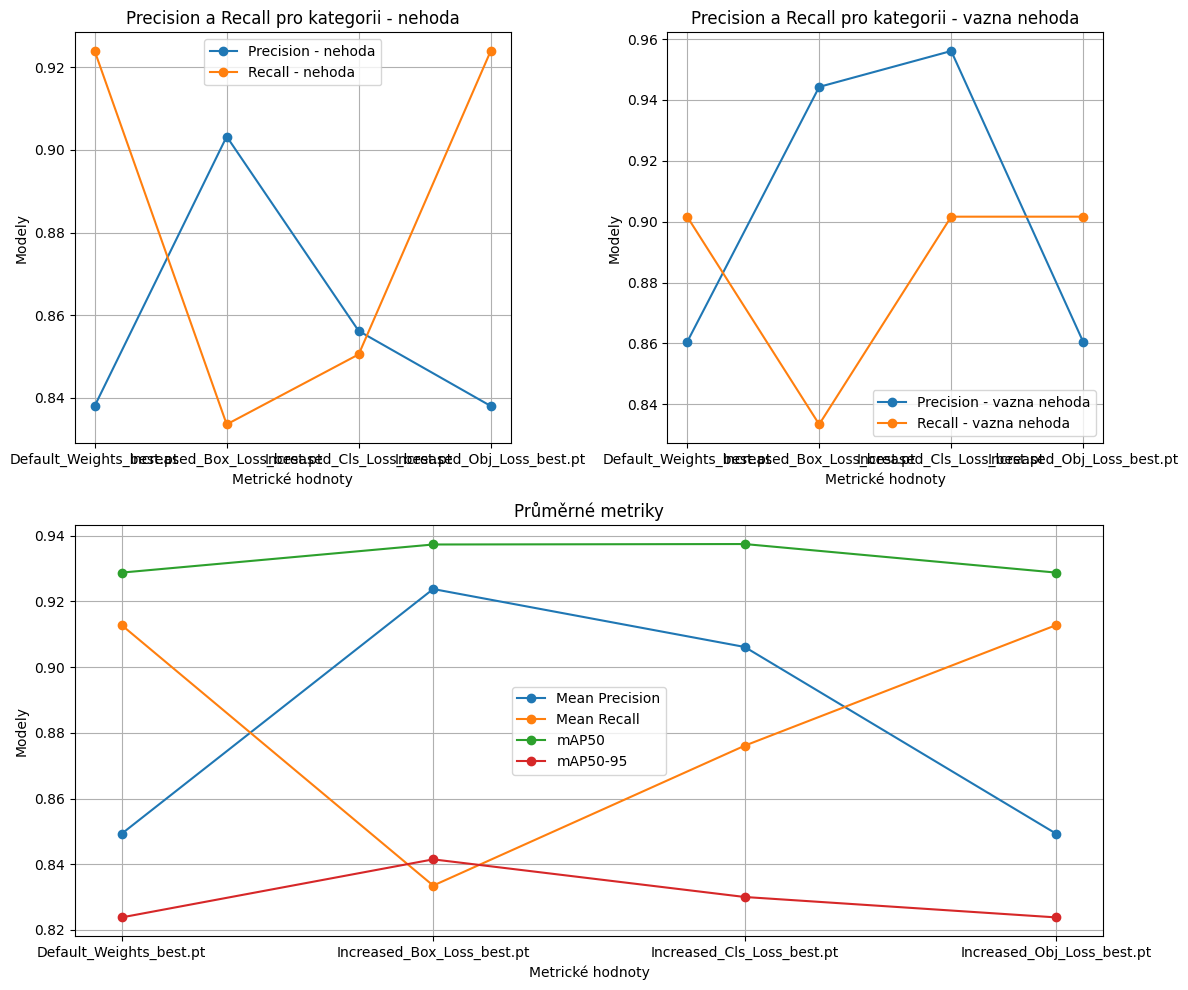

In [ ]:
# List of model paths
models = [
    'Default_Weights_best.pt',
    'Increased_Box_Loss_best.pt',
    'Increased_Cls_Loss_best.pt',
    'Increased_Obj_Loss_best.pt'
]

plot_metrics(models, 'val')

Z grafů můžeme pozorovat, že změna váhy pro objectness loss se na výsledku modelu projeví jen minimálně. Změna při zvýšení váhy u box loss a clasification loss je zřetelnější. V našem případě chceme především zamezit tomu, že nehoda nebude detekována a na místo nevyrazí potřebná pomoc. Tedy preferujeme vyšší hodnotu recall, ale další důležitý rozhodovací paramter je pro nás poměr precision a recall. Přece jen nechceme se ani dostat do situace, kdy náš model způsobí mnoho falešných detekcí nehody, které zbytečně zaměstnají personál.

# *Výsledky*

Na základě předchozí úvahy jsme vybrali model s nastavením vah dle Increased_Cls_Loss. Nyní se podíváme na průběh jeho trénování. Z průběhu loss funkcí můžeme vidět, že train loss stále klesá, ale validation loss už se tolik nemění neboli je téměř konstantní pro všechny složky od osmdesáté epochy. Abych zabránili overfitování modelu, tak jsme trénování ukončily zde. Tento model byl poté integrován do GUI rozhraní, které umožňuje zpracování dat z CCTV kamer v reálném čase a upozornění uživatele na nehodu a následné jeho osobní vyhodnocení, jaké složky záchranného sytému je potřeba k nehodě přivolat.


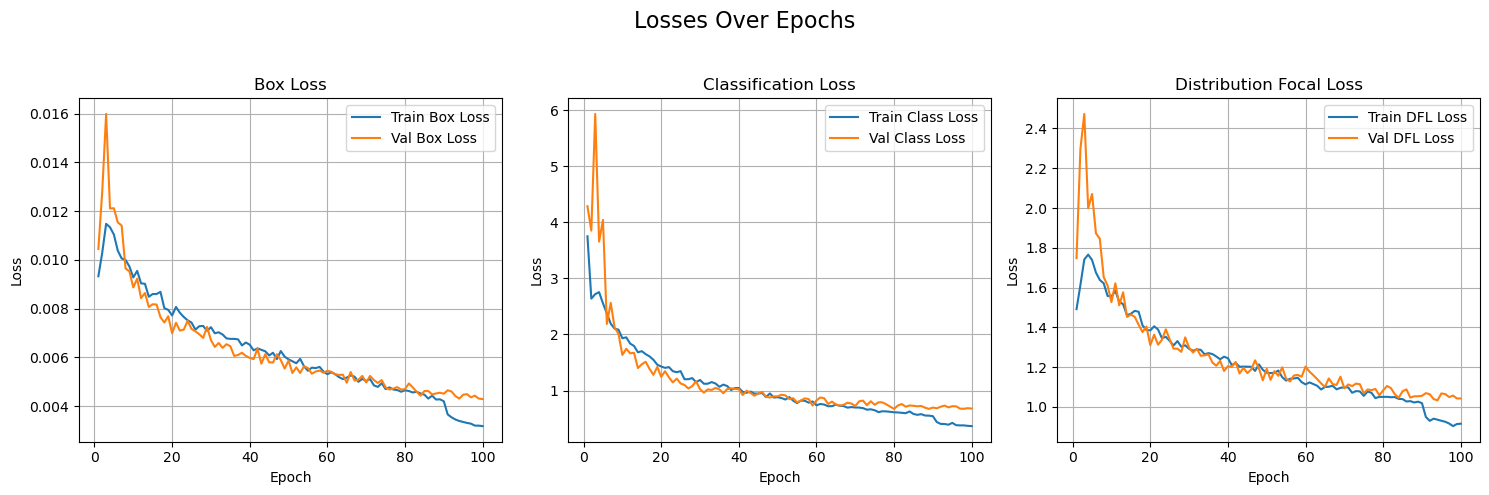

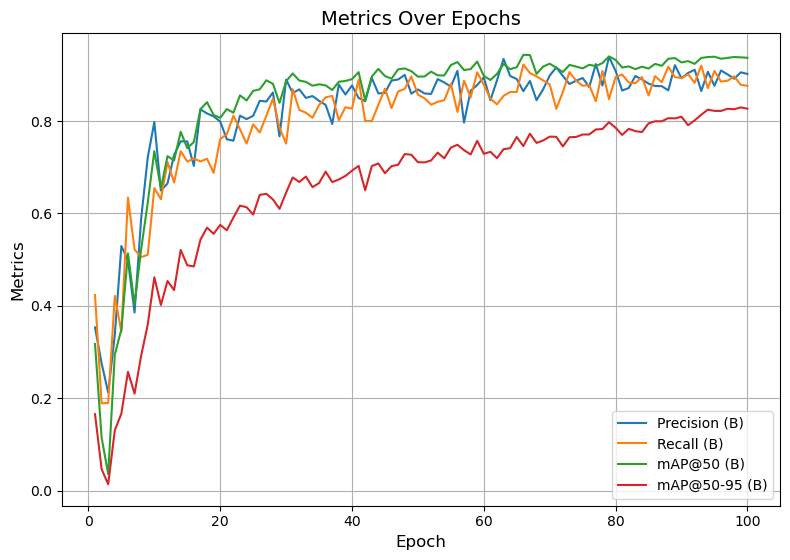

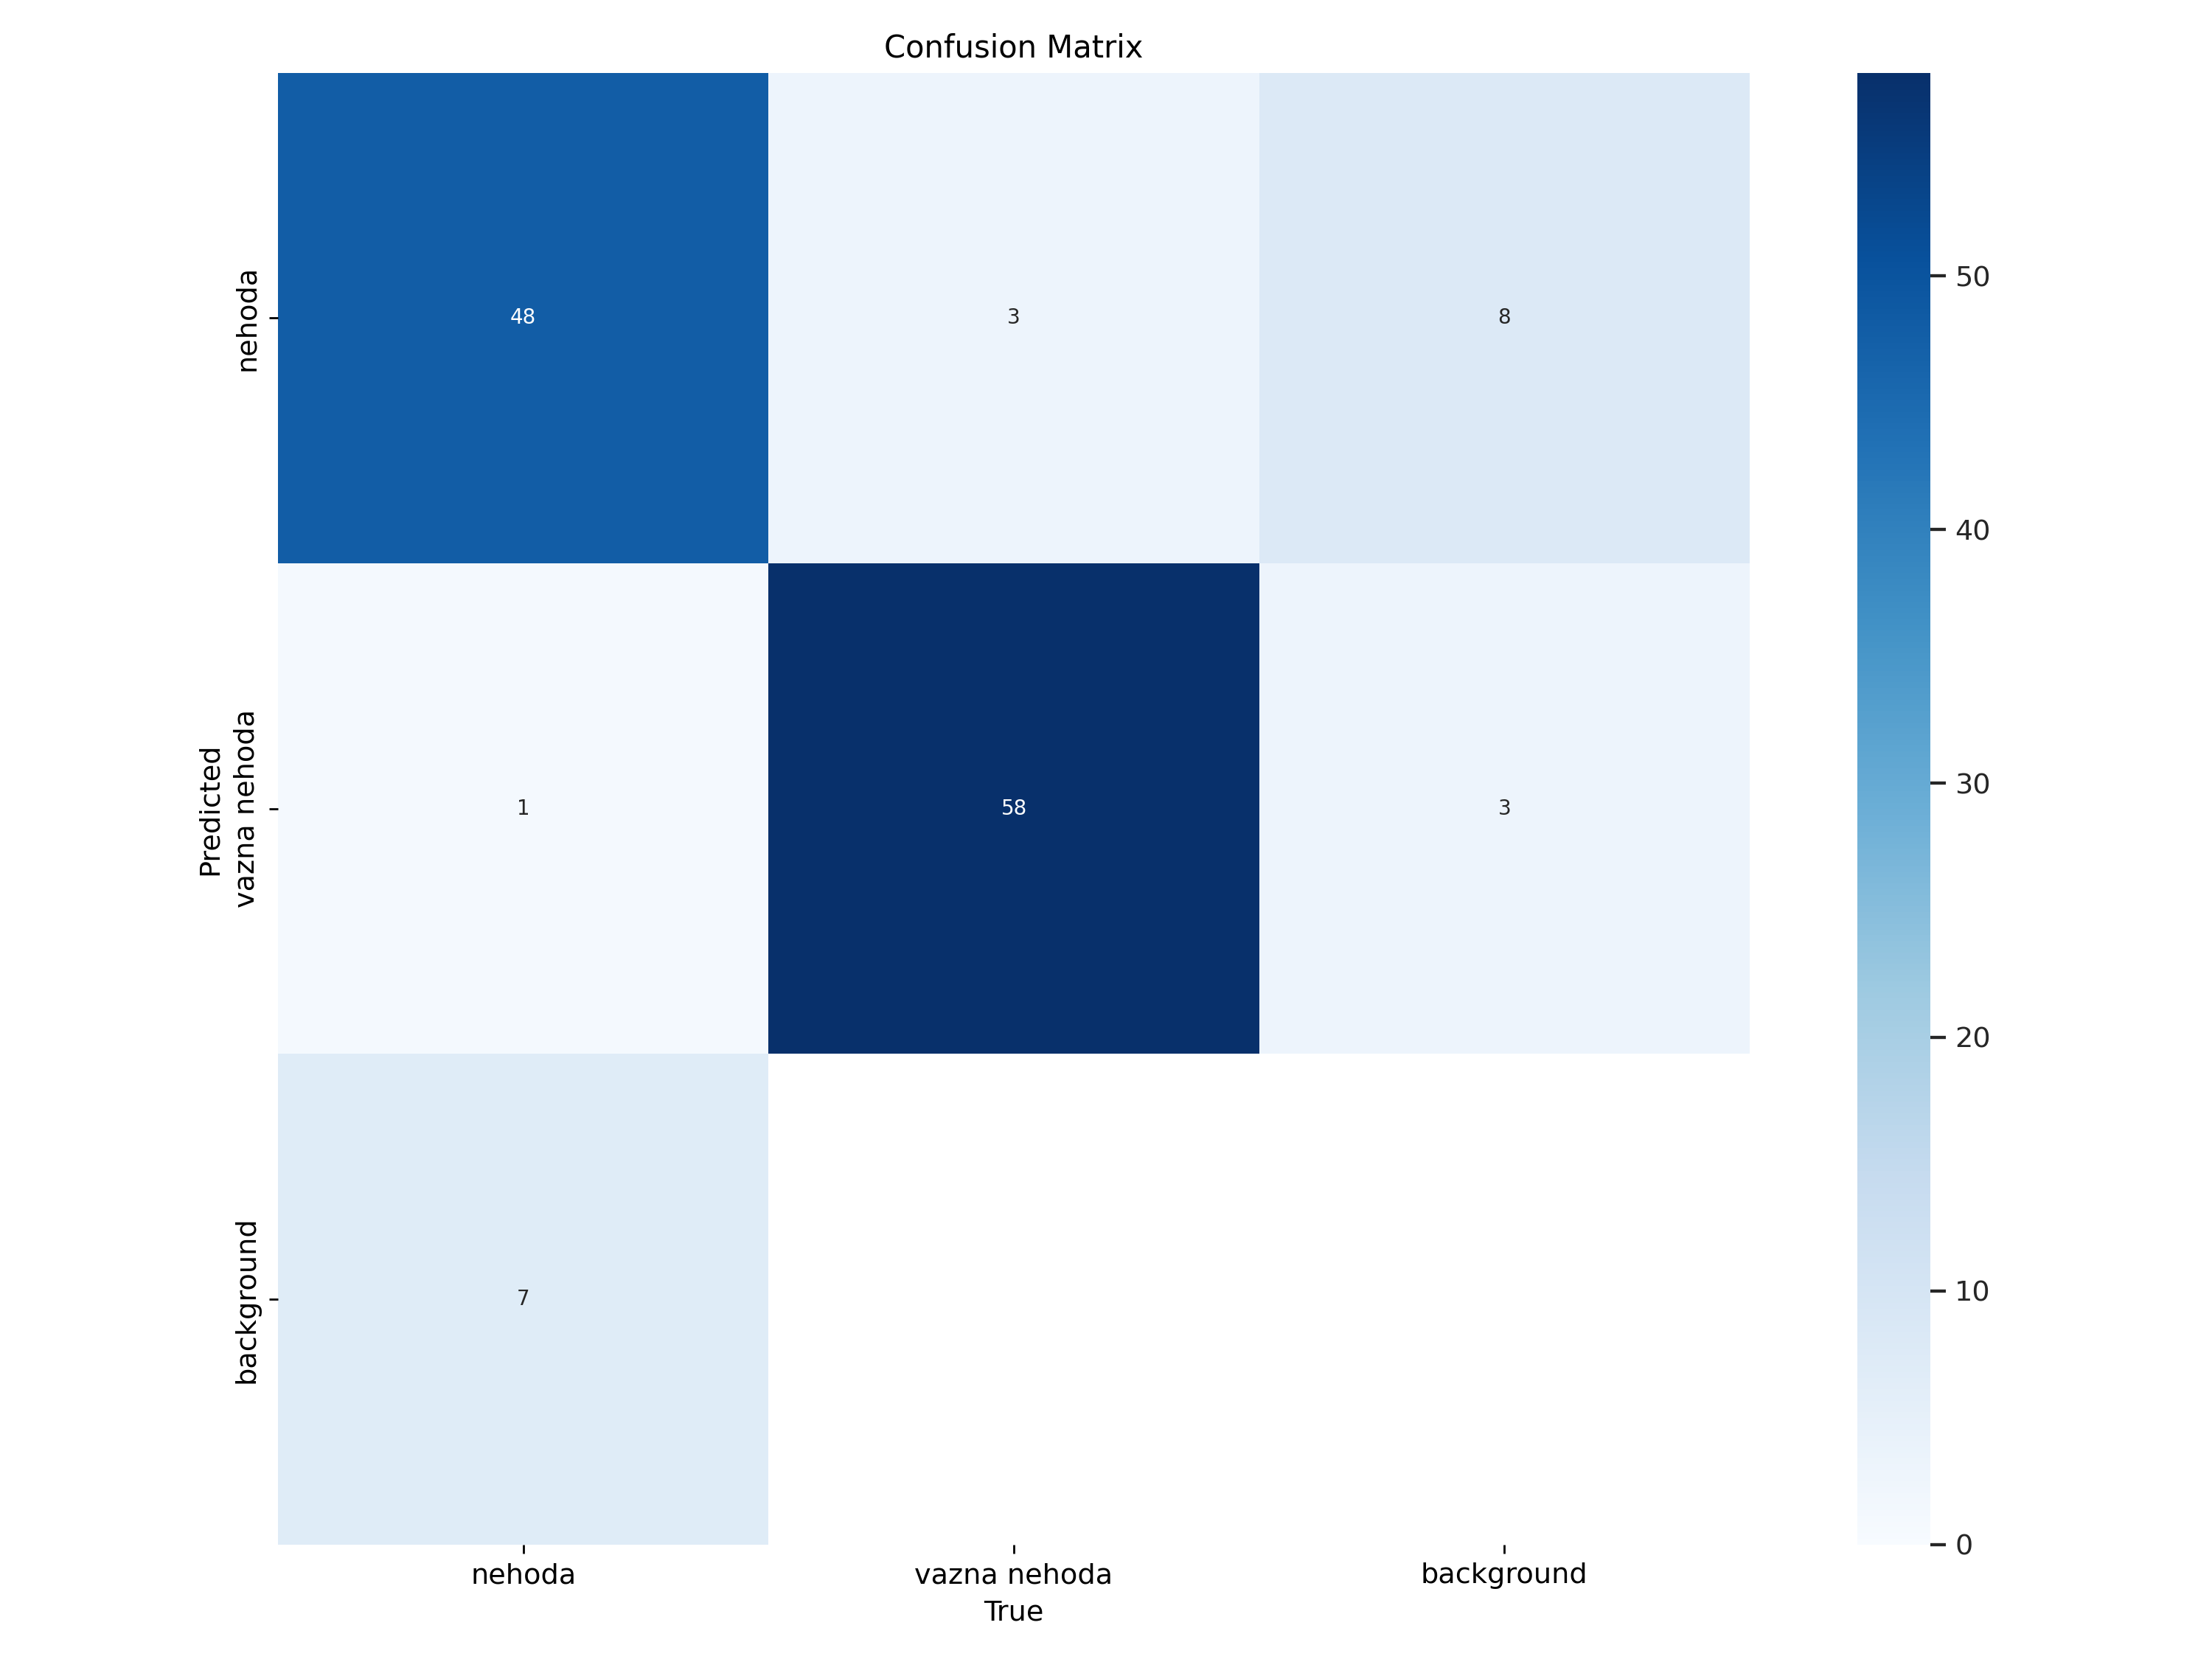

In [ ]:
# Validate the model on the test set
metrics = model.val(data='/content/Road-accident-victim-detection-2/data.yaml', split='val', imgsz=640)

val: Scanning /content/Road-accident-victim-detection-2/valid/labels.cache... 145 images, 34 backgrounds, 0 corrupt: 100%|██████████| 145/145 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:41<00:00, 10.13s/it]


NameError: name 'metrics_data' is not defined

 Model dosáhl přesnosti mAP 93.7% na confidenčním levelu 50% a průměrné přesnosti mAP5-95 83% na 50-95% confidenčním levelu na validačním datasetu a dokázal spolehlivě rozpoznat nehody i na testovacích obrázcích.

\begin{array}{|r|c|c|c|}
\hline
\textbf{Kategorie} & \text{nehoda} & \text{vazna nehoda}\\\\
\hline
Precision & 0.86 & 0.96 \\\\
\hline
Recall & 0.85 & 0.90 \\\\
\hline
\end{array}


 Níže uvádíme graf Precision-Recall.

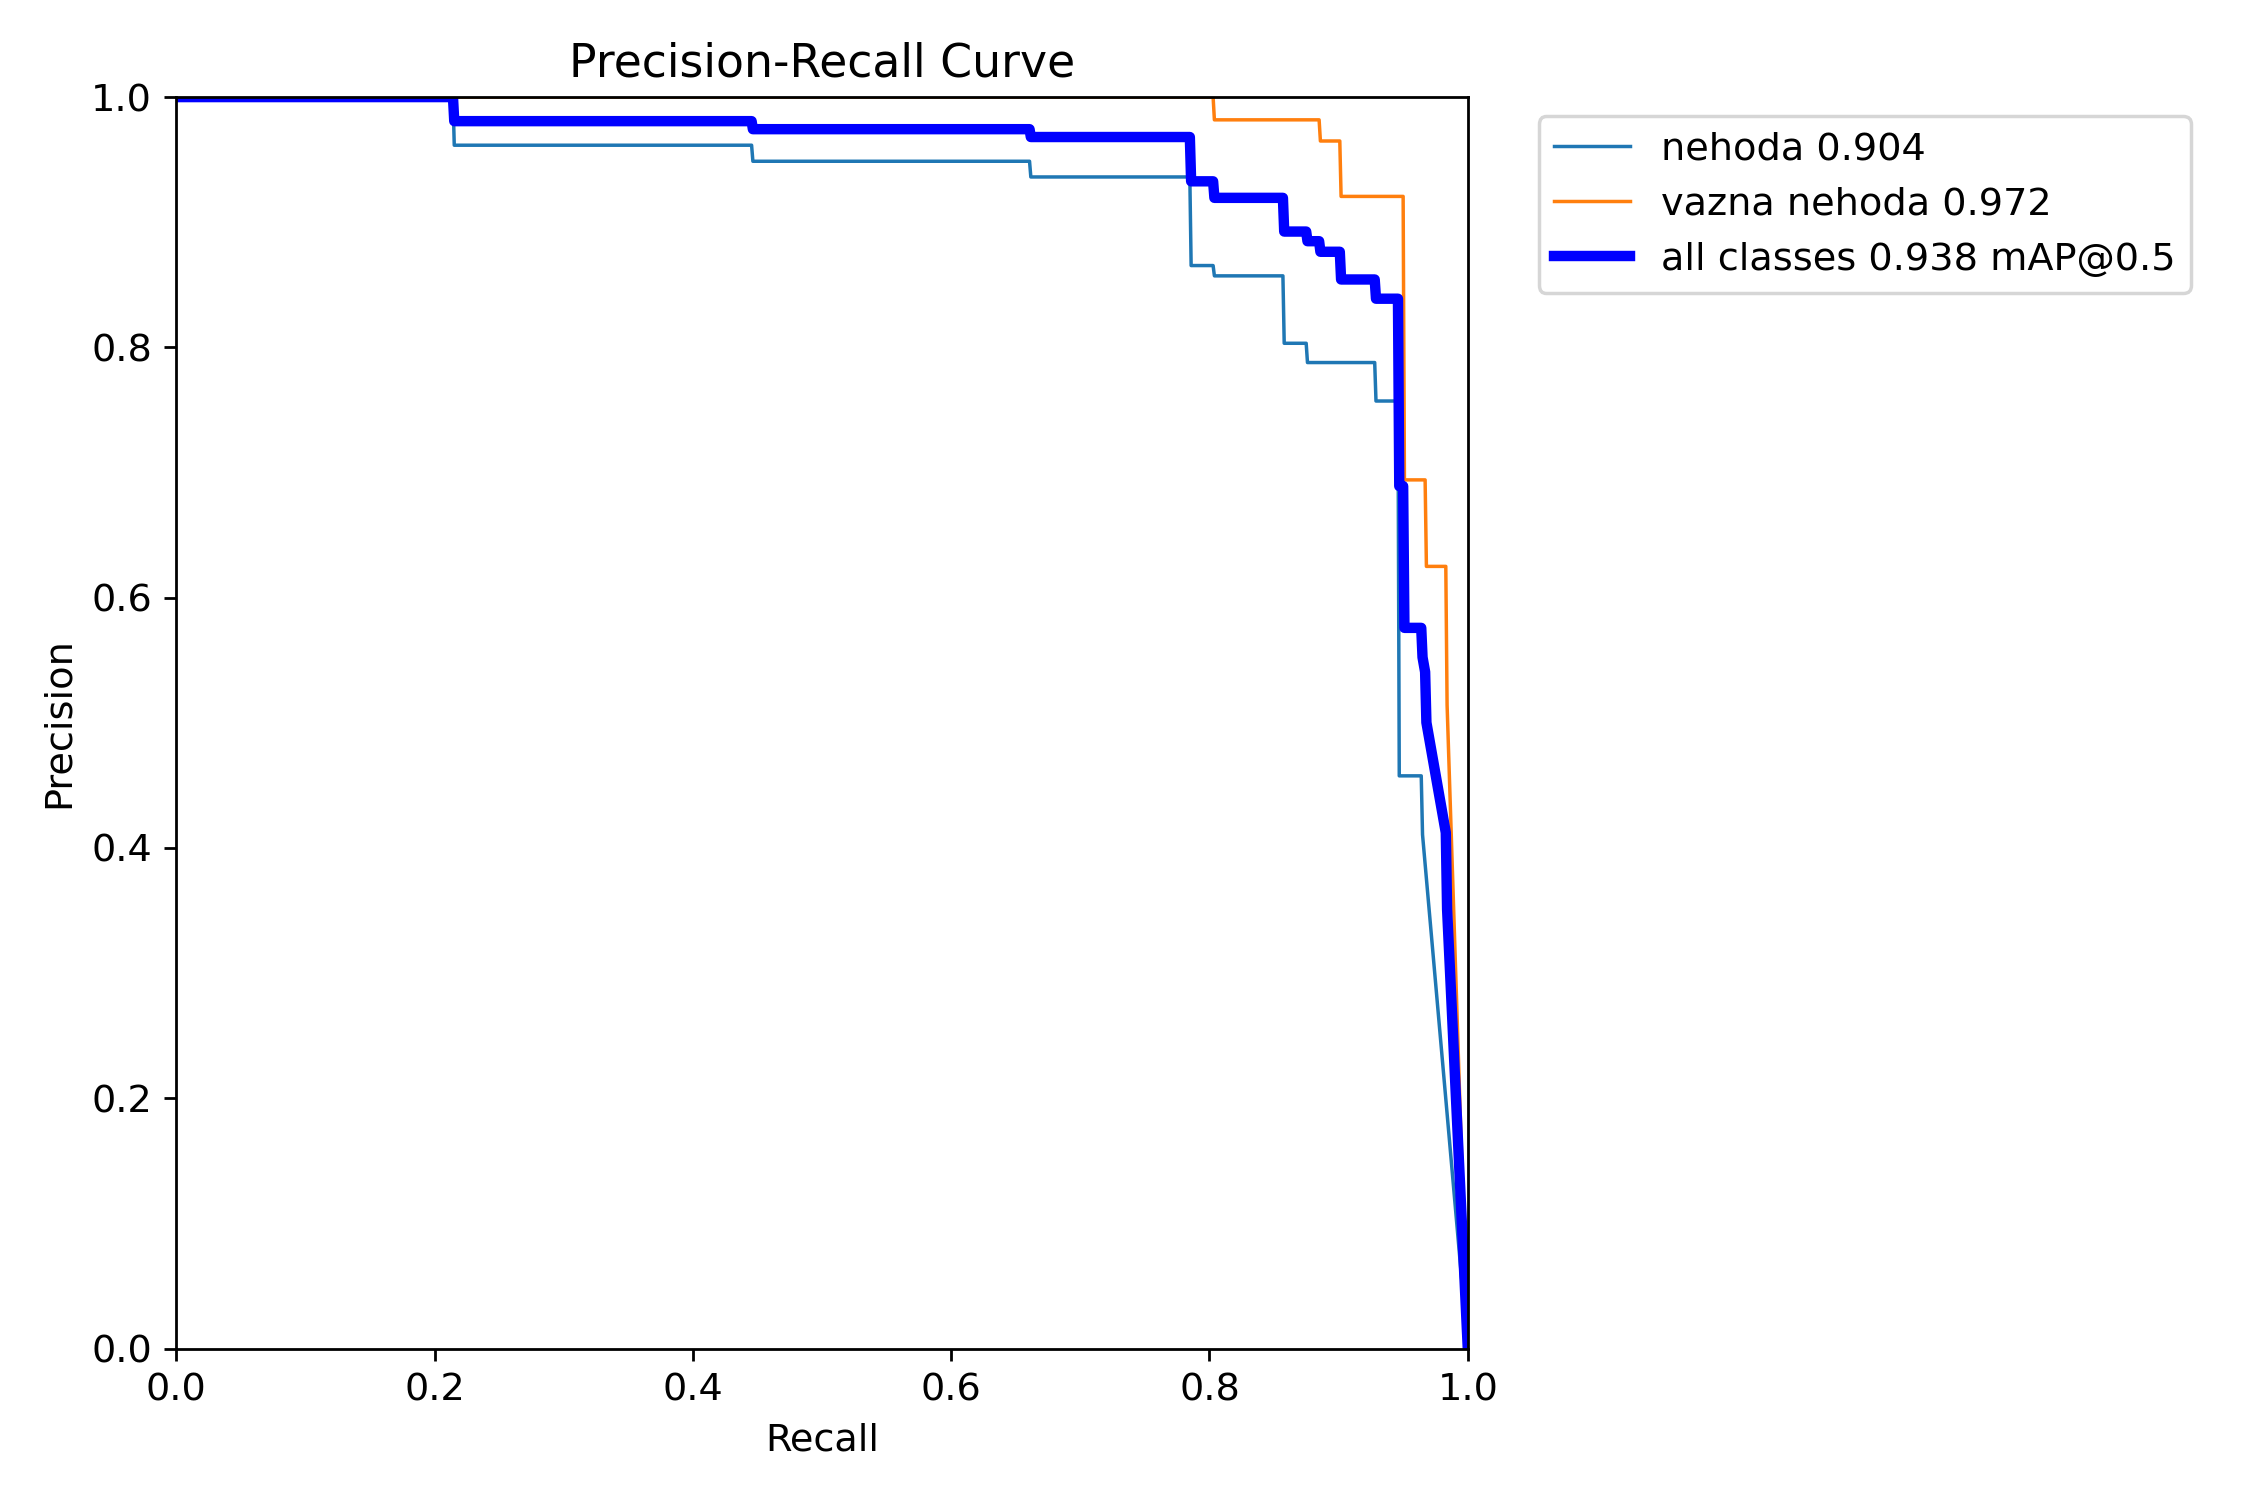

###Demonstrace modelu

Evaluating on image: /content/Road-accident-victim-detection-2/test/images/test21_16_jpg.rf.a4ba0fa3a2290f0b8e2ac0543dd5a9cd.jpg


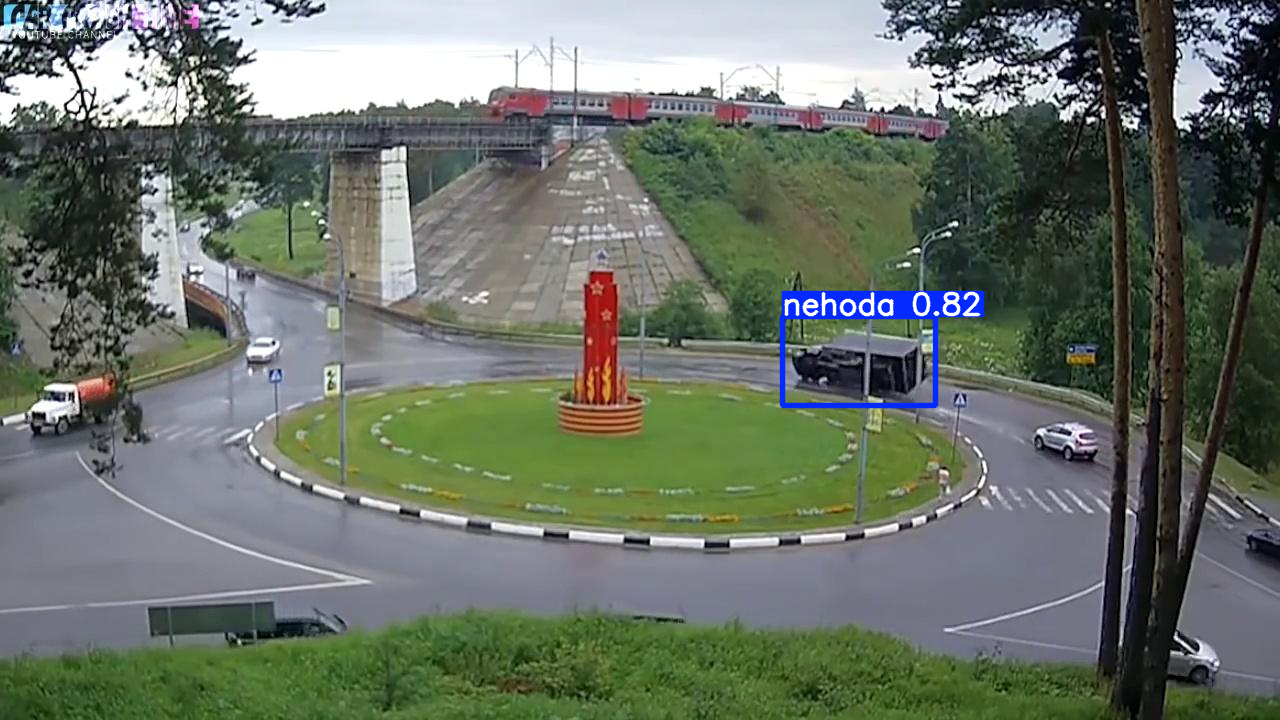

In [ ]:
# Načtení modelu
model = YOLO("/content/2024-final-julia-vendy/Increased_Cls_Loss_best.pt")

# Get a test image
test_images_path = f"{dataset.location}/test/images"  # Path to test images
import os
test_image_file = os.listdir(test_images_path)[143]  # Get the first image in the test folder if you want to test other image from test directory change 1 to a number from 1 to 143
test_image_path = os.path.join(test_images_path, test_image_file)
print(f"Evaluating on image: {test_image_path}")


results = model(test_image_path)
results[0].show()


# *Ukázka použití v praxi*
Pro demonstraci vybraného modelu jsme vytvořili ukázkovou aplikaci (Demo aplikaci), která umožňuje nahrát videa a sledovat, jak model detekuje a klasifikuje dopravní nehody do jednotlivých kategorií. Podrobný návod k instalaci naleznete v souboru README.md v sekci Instalace.



#Závěr

V rámci tohoto projektu jsme vyvinuli aplikaci pro automatickou detekci a klasifikaci dopravních nehod s využitím modelů YOLOv8s. Hlavní motivací bylo zrychlit reakci záchranných složek tím, že eliminuje závislost na přítomnosti svědků, kteří manuálně kontaktují policii nebo záchranné služby. Výsledky našeho řešení ukazují, že navržený systém má potenciál významně přispět k ochraně životů a zdraví lidí tím, že zkrátí dobu potřebnou pro aktivaci potřebné pomoci.

Klíčové poznatky:
1. Výkonnost modelu:
    * Vybraný model dosáhl přesnosti mAP 93,7% při confidenčním levelu 50% a průměrné přesnosti mAP5-95 83% na validačním datasetu.
    * Model úspěšně detekuje a klasifikuje nehody do kategorií s malým počtem falešných detekcí.
2. Optimalizace modelu:
    * Z analýzy různých nastavení váhových parametrů (Objectness Loss, Box Loss a Classification Loss) jsme vybrali konfiguraci Increased_Cls_Loss, která poskytla nejlepší poměr mezi precision a recall.
    * Trénování bylo ukončeno po 100 epochách, kdy validační loss již nevykazoval výrazné změny, čímž jsme předešli overfitování.
3. Integrace do aplikace:
    * Model byl implementován do grafického rozhraní (GUI), které umožňuje reálné zpracování dat.
    * Uživatel je informován o detekované nehodě a může rychle rozhodnout o kontaktování potřebných složek záchranného systému.

Praktická implementace:
Pro demonstraci jsme vytvořili Demo aplikaci, která umožňuje nahrávání videí a sledování práce modelu v reálném čase. Aplikace detekuje nehody a klasifikuje je do kategorií "Těžká nehoda", "Lehká nehoda" a "Bez nehody". Podrobný návod k instalaci aplikace a její spuštění naleznete v souboru README.md v sekci Instalace.

Dalšími kroky by mohlo být:
- Trénování modelu na větším datasetu
- Zahrnutí polohy kamer do aplikace
- Integrace se záchrannými systémy
- Přidání adres kamer do databáze a odesílání adres přímo vybrané záchranné posádce při detekci nehody

# Reference:
 - https://universe.roboflow.com/dronemed/road-accident-victim-detection/dataset/4
 - https://www.kaggle.com/datasets/ckay16/accident-detection-from-cctv-footage